# Chunk store — in-depth investigation

A thorough, self-checking walk through `LineageStore(chunk=True)`: a branching
pipeline with realistic artifacts (CSV, NumPy, images, tables, text), full
artifact and metadata verification, chunk-store analysis with charts, web-graph
checks, a battery of edge cases, and the reclaim path (`compact` / `gc`).

Cells use `assert` liberally — if the notebook runs top to bottom without error,
every check passed.

## 0. Setup and helpers

In [1]:
%matplotlib inline
import json
import os
import shutil
import time
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ancestree
from ancestree.chunkstore import ChunkStore, chunk_bytes, _MIN_SIZE, _MAX_SIZE

# Fresh stores each run so the notebook is reproducible.
# for d in ("chunk_pipeline", "chunk_growth", "chunk_misc"):
#     shutil.rmtree(d, ignore_errors=True)

In [2]:
# --- inspection helpers -------------------------------------------------------
def manifest(store, node_id):
    p = store.root / node_id / ".artifacts.json"
    return json.loads(p.read_text()) if p.exists() else {}

def node_chunks(store, node_id):
    return {c for rec in manifest(store, node_id).values() for c in rec["chunks"]}

def pool_digests(store):
    return list(ChunkStore(store.root).all_digests())

def pool_bytes(store):
    cs = ChunkStore(store.root)
    return sum(cs._path(d).stat().st_size for d in cs.all_digests())

def logical_bytes(store):
    total = 0
    for d in store.root.iterdir():
        for rec in manifest(store, d.name).values():
            total += rec["size"]
    return total

def on_disk_files(store, node_id):
    base = store.root / node_id
    return sorted(
        f.relative_to(base).as_posix()
        for f in base.rglob("*")
        if f.is_file() and f.name not in ("meta.json", ".artifacts.json")
    )

def human(n):
    for unit in ("B", "KB", "MB"):
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} GB"

## 1. Build a branching pipeline

```
ingest ──┬── clean_a ── features ── model ── report
         └── clean_b
```

The two `clean` branches are near-identical large CSVs (they differ only by a
clipped column / a few dropped rows), which is exactly where sub-file chunking
pays off.

In [3]:
RULES = {
    "ingest": [None],
    "clean": ["ingest"],
    "features": ["clean"],
    "model": ["features"],
    "report": ["model"],
}
store = ancestree.LineageStore("chunk_pipeline", rules=RULES, gen_triggers=["ingest"], dedupe=True, chunk=True)

rng = np.random.default_rng(7)
N = 80_000
raw = pd.DataFrame({
    "ts": np.arange(N),
    "sensor": rng.normal(20, 5, N).round(3),
    "temp": rng.normal(50, 10, N).round(3),
    "label": rng.integers(0, 2, N),
})

In [4]:
rng = np.random.default_rng(7) # For the dedupe logic
# ingest -----------------------------------------------------------------------
with store.create_node(step_type="ingest") as ingest:
    raw.to_csv(ingest / "raw.csv", index=False)
    ingest.add_meta("source", "sensor-array-7")
    ingest.add_meta("n_rows", int(len(raw)), group="Stats")
    ingest.add_meta("schema", list(raw.columns), group="Stats")

# two near-identical clean branches --------------------------------------------
clean_a_df = raw.drop(index=rng.choice(N, 40, replace=False)).reset_index(drop=True)
with store.create_node(step_type="clean", parent=ingest) as clean_a:
    clean_a_df.to_csv(clean_a / "clean.csv", index=False)
    clean_a.add_meta("strategy", "dropna")
    clean_a.add_meta("n_rows", int(len(clean_a_df)), group="Stats")

clean_b_df = raw.copy()
clean_b_df["temp"] = clean_b_df["temp"].clip(30, 70)
with store.create_node(step_type="clean", parent=ingest) as clean_b:
    clean_b_df.to_csv(clean_b / "clean.csv", index=False)
    clean_b.add_meta("strategy", "clip_outliers")
    clean_b.add_meta("n_rows", int(len(clean_b_df)), group="Stats")

# features ---------------------------------------------------------------------
with store.create_node(step_type="features", parent=clean_a) as features:
    X = np.c_[clean_a_df["sensor"], clean_a_df["temp"], clean_a_df["sensor"] * clean_a_df["temp"]]
    np.save(features / "X.npy", X)
    features.add_meta("n_features", int(X.shape[1]), group="Stats")
    features.add_meta("recipe", "sensor, temp, sensor*temp", data_type="code")

# model (rich metadata: metric, params, image, link, table) --------------------
with store.create_node(step_type="model", parent=features) as model:
    w = rng.normal(size=3)
    (model / "model.pkl").write_bytes(w.tobytes())
    acc = float(rng.uniform(0.80, 0.95))
    model.add_meta("accuracy", round(acc, 4), group="Metrics")
    model.add_meta("params", {"lr": 0.01, "epochs": 20, "optimizer": "adam"}, group="Config")
    cm = rng.integers(0, 100, (2, 2))
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(cm, cmap="Blues"); ax.set_title("confusion")
    fig.savefig(model / "confusion.png", dpi=80); plt.close(fig)
    model.add_meta("confusion", model / "confusion.png", data_type="image", group="Figures")
    model.add_meta("dashboard", "https://example.com/run/123", data_type="link", group="Links")
    model.add_meta("per_class", pd.DataFrame({"class": [0, 1], "f1": [0.81, 0.88]}),
                   data_type="table", group="Metrics")

# report -----------------------------------------------------------------------
with store.create_node(step_type="report", parent=model) as report:
    (report / "summary.md").write_text(f"# Report\n\nAccuracy: {acc:.3f}\n")
    fig, ax = plt.subplots(figsize=(3, 2))
    ax.bar(["class 0", "class 1"], [0.81, 0.88], color=["#4c72b0", "#dd8452"])
    fig.savefig(report / "f1.png", dpi=80, ); plt.close(fig)
    report.add_meta("verdict", "ship it")

pipeline = {"ingest": ingest, "clean_a": clean_a, "clean_b": clean_b,
            "features": features, "model": model, "report": report}
print("built nodes:", {k: v.node_id for k, v in pipeline.items()})
# plt.show()

built nodes: {'ingest': '98e30862', 'clean_a': 'd24976ba', 'clean_b': '9993af9e', 'features': '429b9a4f', 'model': '82630226', 'report': '1792e76d'}


In [5]:
# store.compact()

In [ ]:
store.generate_web_graph()
store.compact()

In [7]:
# store.generate_web_graph()
# # 6,240,442 bytes (8.4 MB on disk) for 74 items
# # 8,917,034 bytes (51.2 MB on disk) for 122 items
# store.compact()

In [8]:
# Every artifact file was packed away: nothing but meta.json + manifest remains.
for name, node in pipeline.items():
    assert on_disk_files(store, node.node_id) == [], f"{name} still has loose files"
    assert (store.root / node.node_id / ".artifacts.json").exists()
print("all artifacts packed — node directories hold only metadata + recipes")
print("chunk pool:", len(pool_digests(store)), "chunks,", human(pool_bytes(store)))

all artifacts packed — node directories hold only metadata + recipes
chunk pool: 584 chunks, 2.7 MB


In [9]:
# with store.create_node(step_type='something', parent=store.get_most_recent_node()) as node:
#     node.add_meta('key', 5, 'something')

In [10]:
# store.compact()

In [11]:
# n = store.get_most_recent_node(step_type='ingest')
# n.artifacts()

# pd.read_csv(n.artifacts()[0])

## 2. Artifact verification — every file round-trips through the chunk store

In [12]:
import hashlib

rows = []
for name, node in pipeline.items():
    reopened = store.get_node(node.node_id)
    for rel, rec in manifest(store, node.node_id).items():
        data = Path(reopened / rel).read_bytes()  # `reopened / rel` rehydrates on access
        # integrity: bytes match the recorded size and hash, and reassembly is exact
        assert len(data) == rec["size"]
        assert hashlib.sha256(data).hexdigest() == rec["sha256"]
        rows.append({"node": name, "artifact": rel, "size": rec["size"],
                     "chunks": len(rec["chunks"])})

artifact_table = pd.DataFrame(rows).sort_values(["node", "artifact"]).reset_index(drop=True)
print("verified", len(artifact_table), "artifacts — all hashes match")
artifact_table

verified 8 artifacts — all hashes match


,node,artifact,size,chunks
0,clean_a,clean.csv,1728723,167
1,clean_b,clean.csv,1722764,166
2,features,X.npy,1919168,214
3,ingest,raw.csv,1729595,167
4,model,confusion.png,6750,1
5,model,model.pkl,24,1
6,report,f1.png,3633,1
7,report,summary.md,26,1


In [13]:
# artifacts() lists logical names and resolves them to readable bytes
listing = {name: [p.name for p in store.get_node(node.node_id).artifacts()]
           for name, node in pipeline.items()}
assert listing["model"] == sorted(["model.pkl", "confusion.png"])
assert store.get_node(report.node_id).artifacts("*.md")  # glob filter still works
print(json.dumps(listing, indent=2))

{
  "ingest": [
    "raw.csv"
  ],
  "clean_a": [
    "clean.csv"
  ],
  "clean_b": [
    "clean.csv"
  ],
  "features": [
    "X.npy"
  ],
  "model": [
    "confusion.png",
    "model.pkl"
  ],
  "report": [
    "f1.png",
    "summary.md"
  ]
}


In [14]:
# n = store.get_most_recent_node(step_type='report')


# import matplotlib.image as mpimg
# img = mpimg.imread(n.artifacts()[0])
# plt.imshow(img)
# plt.axis('off')


## 3. Metadata verification (survives reopen, search, lineage)

In [15]:
# Reopen the store from scratch: the index and recipes are read back from disk.
fresh = ancestree.LineageStore("chunk_pipeline", chunk=True)

m = fresh.get_node(model.node_id).metadata
assert m["accuracy"]["value"] == round(acc, 4)
assert m["params"]["value"]["optimizer"] == "adam"
assert m["per_class"]["data_type"] == "table"
assert m["healthy"]["value"] is True
assert "size_mb" in m and "duration_s" in m  # content_hash only appears with dedupe=True
# image metadata path is node-id-relative and still points at a (rehydratable) file
print("model metadata groups:", sorted({v["group"] for v in m.values()}))
print("accuracy:", m["accuracy"]["value"], "| size_mb:", m["size_mb"]["value"])

model metadata groups: ['Config', 'Figures', 'Links', 'Metrics', 'Provenance', 'Structural Properties']
accuracy: 0.9271 | size_mb: 0.006774


In [16]:
# Search and lineage work exactly as without chunking.
assert {n.node_id for n in fresh.find_node(step_type="clean")} == {clean_a.node_id, clean_b.node_id}
assert fresh.find_node(accuracy=lambda a: a is not None and a > 0.5)
lineage = [n.step_type for n in fresh.get_lineage(report.node_id)]
assert lineage == ["ingest", "clean", "features", "model", "report"]
assert [n.step_type for n in fresh.find_in_lineage(report.node_id, step_type="clean")] == ["clean"]
print("lineage of report:", " -> ".join(lineage))

# reserved key guard still holds
with fresh.create_node(step_type="ingest") as probe:
    probe.add_meta("ok", 1)
    try:
        probe.add_meta("content_hash", "x"); raised = False
    except ValueError:
        raised = True
assert raised
fresh.prune(probe, dry_run=False)  # drop the throwaway probe node
print("reserved-key guard works; throwaway node pruned")

lineage of report: ingest -> clean -> features -> model -> report
reserved-key guard works; throwaway node pruned


## 4. Chunk-store analysis

In [17]:
log_b, phys_b = logical_bytes(store), pool_bytes(store)
print(f"logical artifact bytes : {human(log_b)}")
print(f"physical chunk bytes   : {human(phys_b)}  ({phys_b / log_b:.1%} of logical)")

def shared(a, b):
    return len(node_chunks(store, pipeline[a].node_id) & node_chunks(store, pipeline[b].node_id))

print("\ncross-node chunk sharing:")
print(f"  ingest.raw  <-> clean_a.clean : {shared('ingest', 'clean_a')} shared "
      "(rows only dropped -> long identical runs survive)")
print(f"  clean_a     <-> clean_b       : {shared('clean_a', 'clean_b')} shared "
      "(temp clipped on scattered rows -> almost every chunk differs)")

logical artifact bytes : 6.8 MB
physical chunk bytes   : 2.7 MB  (40.5% of logical)

cross-node chunk sharing:
  ingest.raw  <-> clean_a.clean : 134 shared (rows only dropped -> long identical runs survive)
  clean_a     <-> clean_b       : 0 shared (temp clipped on scattered rows -> almost every chunk differs)


> **What this shows.** Chunking deduplicates *contiguous* identical byte runs.
> `clean_a` merely drops a few rows, so long stretches of the table survive
> untouched and share many chunks with `ingest`. `clean_b` clips `temp` on rows
> scattered throughout the file, so nearly every chunk contains at least one changed
> value and little is shared — even though the file is "95% the same". The growth
> experiment below makes the contrast concrete: a *localised* edit shares almost
> everything. The pool is still well under the logical size here thanks to chunk
> compression and intra-file repetition.

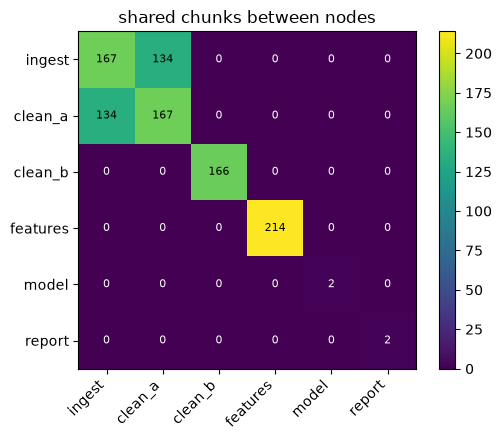

In [18]:
# Chunk-sharing matrix across the pipeline nodes.
names = list(pipeline)
csets = [node_chunks(store, pipeline[n].node_id) for n in names]
M = np.array([[len(csets[i] & csets[j]) for j in range(len(names))] for i in range(len(names))])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap="viridis")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, M[i, j], ha="center", va="center",
                color="white" if M[i, j] < M.max() / 2 else "black", fontsize=8)
ax.set_title("shared chunks between nodes")
fig.colorbar(im, fraction=0.046); fig.tight_layout(); plt.show()

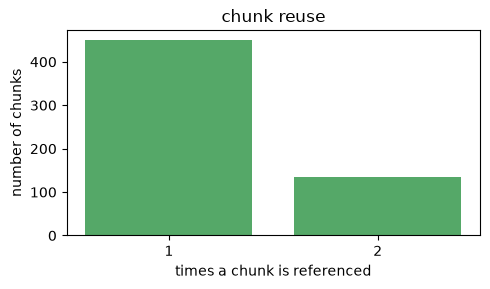

reused (>1 reference) chunks: 134


In [19]:
# Reference-count histogram: how many artifacts point at each chunk.
from collections import Counter
refs = Counter()
for d in store.root.iterdir():
    for rec in manifest(store, d.name).values():
        for c in rec["chunks"]:
            refs[c] += 1
counts = Counter(refs.values())
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([str(k) for k in sorted(counts)], [counts[k] for k in sorted(counts)], color="#55a868")
ax.set_xlabel("times a chunk is referenced"); ax.set_ylabel("number of chunks")
ax.set_title("chunk reuse"); fig.tight_layout(); plt.show()
print("reused (>1 reference) chunks:", sum(v for k, v in counts.items() if k > 1))

### Pool growth as near-identical data accumulates

Add successive snapshots of one big table, each a small mutation of the last.
Whole-file storage would grow linearly; the chunk pool grows only by each
snapshot's *differences*.

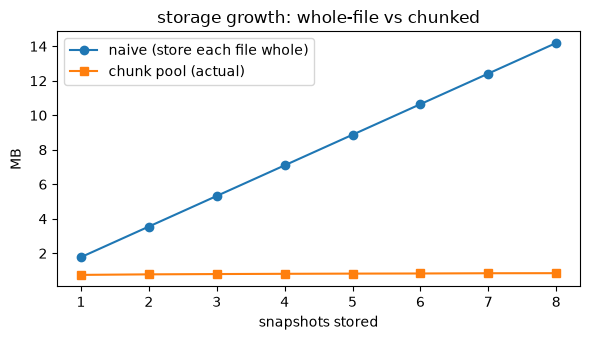

after 8 snapshots: naive 13.5 MB vs pool 826.7 KB (6.0%)


In [20]:
growth = ancestree.LineageStore("chunk_growth", chunk=True)
big = pd.DataFrame(rng.normal(size=(60_000, 4)).round(4), columns=list("abcd"))
naive, actual = [], []
running_whole = 0
for i in range(8):
    snap = big.copy()
    snap.iloc[i * 500:(i * 500) + 200, 0] += 1.0  # mutate a small contiguous block
    with growth.create_node(step_type="snapshot") as node:
        snap.to_csv(node / "table.csv", index=False)
    running_whole += manifest(growth, node.node_id)["table.csv"]["size"]
    naive.append(running_whole)
    actual.append(pool_bytes(growth))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, 9), [b / 1e6 for b in naive], "o-", label="naive (store each file whole)")
ax.plot(range(1, 9), [b / 1e6 for b in actual], "s-", label="chunk pool (actual)")
ax.set_xlabel("snapshots stored"); ax.set_ylabel("MB"); ax.legend()
ax.set_title("storage growth: whole-file vs chunked"); fig.tight_layout(); plt.show()
print(f"after 8 snapshots: naive {human(naive[-1])} vs pool {human(actual[-1])} "
      f"({actual[-1] / naive[-1]:.1%})")

## 5. Visualisation: the interactive web graph

In [21]:
html_path = store.generate_web_graph()
html = Path(html_path).read_text()
assert Path(html_path).exists() and len(html) > 10_000
# generating the graph calls artifacts(), which rehydrates packed files —
# so the inline images now exist on disk for the HTML to reference.
for node in (model, report):
    imgs = [p for p in store.get_node(node.node_id).artifacts("*.png")]
    for img in imgs:
        assert (store.root / img).exists()
assert all(nid in html for nid in (ingest.node_id, report.node_id))
print(f"web graph: {human(len(html.encode()))} of HTML at {html_path}")
print("inline images rehydrated for rendering:",
      [p.name for p in store.get_node(model.node_id).artifacts('*.png')])

AssertionError: 

## 6. Edge cases

In [ ]:
misc = ancestree.LineageStore("chunk_misc", chunk=True)

def store_one(payload, name="f.bin"):
    with misc.create_node(step_type="x") as n:
        (n / name).write_bytes(payload)
    return n

# (a) empty file -> zero chunks, round-trips to b""
empty = store_one(b"")
assert manifest(misc, empty.node_id)["f.bin"]["chunks"] == []
assert (misc.get_node(empty.node_id) / "f.bin").read_bytes() == b""

# (b) tiny file (< min chunk) -> exactly one chunk
tiny = store_one(b"hello world")
assert len(manifest(misc, tiny.node_id)["f.bin"]["chunks"]) == 1

# (c) large file -> many chunks, each within FastCDC bounds
big_payload = os.urandom(3_000_000)
large = store_one(big_payload)
clens = [len(zlib.decompress(ChunkStore(misc.root)._path(c).read_bytes()))
         for c in manifest(misc, large.node_id)["f.bin"]["chunks"]]
assert all(_MIN_SIZE <= L <= _MAX_SIZE for L in clens[:-1])
assert (misc.get_node(large.node_id) / "f.bin").read_bytes() == big_payload
print(f"large file: {len(clens)} chunks, sizes {human(min(clens))}..{human(max(clens))}")

# (d) identical content in two nodes -> pool does not grow
pool_before = set(pool_digests(misc))
twin = store_one(big_payload)
assert set(pool_digests(misc)) == pool_before
assert node_chunks(misc, twin.node_id) == node_chunks(misc, large.node_id)
print("identical file in a second node added 0 new chunks")

# (e) one-byte change -> only a couple of new chunks
edited = bytearray(big_payload); edited[1_500_000] ^= 0xFF
edit_node = store_one(bytes(edited))
new = node_chunks(misc, edit_node.node_id) - node_chunks(misc, large.node_id)
print("one flipped byte produced", len(new), "new chunk(s)")
assert len(new) <= 3

large file: 328 chunks, sizes 2.0 KB..18.7 KB


identical file in a second node added 0 new chunks


one flipped byte produced 1 new chunk(s)


In [ ]:
# (f) a failed (unhealthy) run is NOT packed — partial work stays as a real file
try:
    with misc.create_node(step_type="x") as boom:
        (boom / "partial.bin").write_bytes(b"half" * 5000)
        raise RuntimeError("kaboom")
except RuntimeError:
    pass
assert (misc.root / boom.node_id / "partial.bin").exists()
assert not (misc.root / boom.node_id / ".artifacts.json").exists()
assert misc.get_node(boom.node_id).metadata["healthy"]["value"] is False
print("failed run kept partial.bin unpacked, flagged unhealthy")

# (g) integrity: corrupting a chunk is caught when a file is reassembled.
# A materialised file is a trusted cache, so first remove the on-disk copy to
# force a rebuild, and corrupt a chunk that actually belongs to this file.
(misc.root / large.node_id / "f.bin").unlink(missing_ok=True)
victim = manifest(misc, large.node_id)["f.bin"]["chunks"][0]
ChunkStore(misc.root)._path(victim).write_bytes(zlib.compress(b"tampered"))
try:
    _ = misc.get_node(large.node_id) / "f.bin"
    caught = "NO ERROR (unexpected!)"
except RuntimeError as e:
    caught = str(e)[:70]
print("corruption caught ->", caught)
assert caught.startswith("Artifact")

failed run kept partial.bin unpacked, flagged unhealthy
corruption caught -> Artifact 'f.bin' failed its integrity check while being reassembled — 


In [ ]:
# (h) dedupe + chunk together: identical node reused, near-identical kept + shared
combo = ancestree.LineageStore(Path("chunk_misc") / "combo", dedupe=True, chunk=True)
blob = os.urandom(120_000)
def run(payload):
    with combo.create_node(step_type="x") as n:
        (n / "d.bin").write_bytes(payload); n.add_meta("k", 1)
    return n
n1, n2 = run(blob), run(blob)
assert n2.node_id == n1.node_id  # whole-node dedup still fires
near = bytearray(blob); near[60_000] ^= 1
n3 = run(bytes(near))
assert n3.node_id != n1.node_id and (node_chunks(combo, n3.node_id) & node_chunks(combo, n1.node_id))
print("dedupe collapsed the identical run; near-identical kept but shares chunks")

dedupe collapsed the identical run; near-identical kept but shares chunks


## 7. Reclaiming space — `compact` and `gc`

In [ ]:
# Reading rehydrates a real copy; compact() re-packs and removes it.
art = store.get_node(clean_a.node_id) / "clean.csv"
assert Path(art).exists(), "reading should have materialised the file"
disk_before = sum(f.stat().st_size for f in (store.root / clean_a.node_id).rglob('*') if f.is_file())
store.compact()
assert not (store.root / clean_a.node_id / "clean.csv").exists()
disk_after = sum(f.stat().st_size for f in (store.root / clean_a.node_id).rglob('*') if f.is_file())
print(f"compact re-packed clean_a: node dir {human(disk_before)} -> {human(disk_after)}")
assert (store.get_node(clean_a.node_id) / "clean.csv").exists()  # still readable

compact re-packed clean_a: node dir 1.7 MB -> 14.2 KB


In [ ]:
# Pruning a branch orphans the chunks only it referenced; gc reclaims them.
preview = store.prune(clean_b, dry_run=True)
print("dry-run would delete:", [n.node_id for n in preview])

pool_before = len(pool_digests(store))
b_only = node_chunks(store, clean_b.node_id) - (
    set().union(*(node_chunks(store, pipeline[k].node_id)
                  for k in pipeline if k != "clean_b")))
store.prune(clean_b, dry_run=False)  # triggers gc, but fresh chunks are spared by the grace window
print(f"immediately after prune: pool {pool_before} -> {len(pool_digests(store))} "
      "(grace window protects just-written chunks)")

# Simulate the grace window elapsing, then collect for real.
cs = ChunkStore(store.root); past = time.time() - 120
for d in cs.all_digests():
    os.utime(cs._path(d), (past, past))
reclaimed = store.gc()
print(f"after ageing + gc(): reclaimed {reclaimed} orphan chunks, pool now {len(pool_digests(store))}")
assert reclaimed >= len(b_only) - 0  # clean_b's exclusive chunks are gone

dry-run would delete: ['ff6fa717']
immediately after prune: pool 588 -> 588 (grace window protects just-written chunks)
after ageing + gc(): reclaimed 166 orphan chunks, pool now 422


## 8. Summary

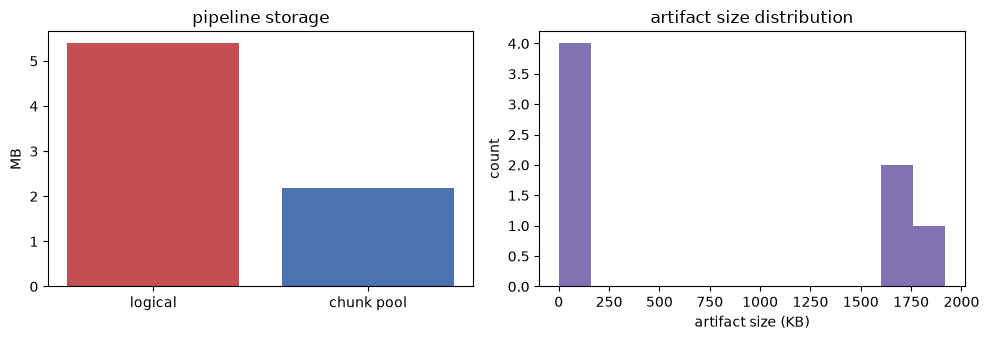

Investigation complete — all assertions passed.
  pipeline nodes : 6
  logical bytes  : 5.1 MB
  chunk pool     : 422 chunks, 2.1 MB


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(["logical", "chunk pool"], [logical_bytes(store) / 1e6, pool_bytes(store) / 1e6],
            color=["#c44e52", "#4c72b0"])
axes[0].set_ylabel("MB"); axes[0].set_title("pipeline storage")
sizes = [r["size"] for d in store.root.iterdir() for r in manifest(store, d.name).values()]
axes[1].hist(np.array(sizes) / 1e3, bins=12, color="#8172b3")
axes[1].set_xlabel("artifact size (KB)"); axes[1].set_ylabel("count")
axes[1].set_title("artifact size distribution")
fig.tight_layout(); plt.show()

print("Investigation complete — all assertions passed.")
print(f"  pipeline nodes : {len(pipeline)}")
print(f"  logical bytes  : {human(logical_bytes(store))}")
print(f"  chunk pool     : {len(pool_digests(store))} chunks, {human(pool_bytes(store))}")